<a href="https://colab.research.google.com/github/albertocj1/CCDATSCL_EXAM_COM221/blob/main/CCDATSCL_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [ ]:
import os
import pandas as pd

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

In [ ]:
df.head(10)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
print("Descriptive statistics for 'lead_time':")
print(df['lead_time'].describe())

Descriptive statistics for 'lead_time':
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


In [ ]:
print("Descriptive statistics for 'adr':")
print(df['adr'].describe())

Descriptive statistics for 'adr':
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

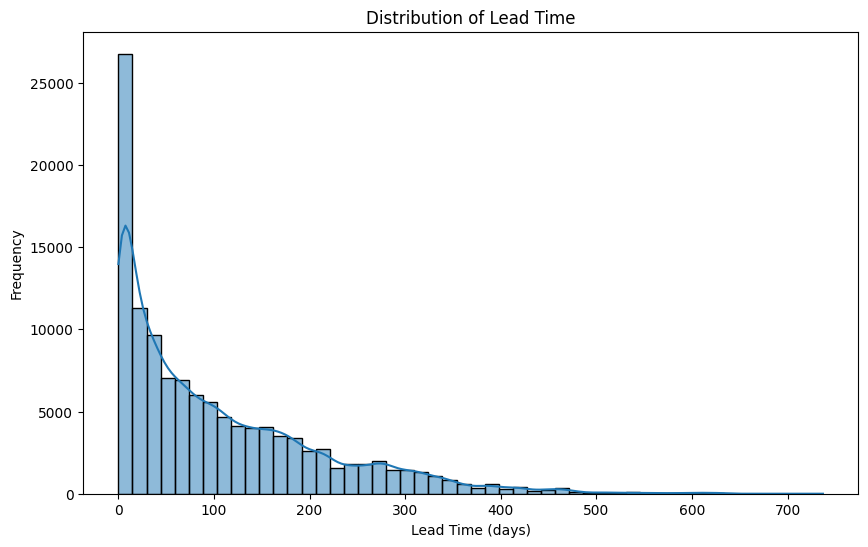

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.show()

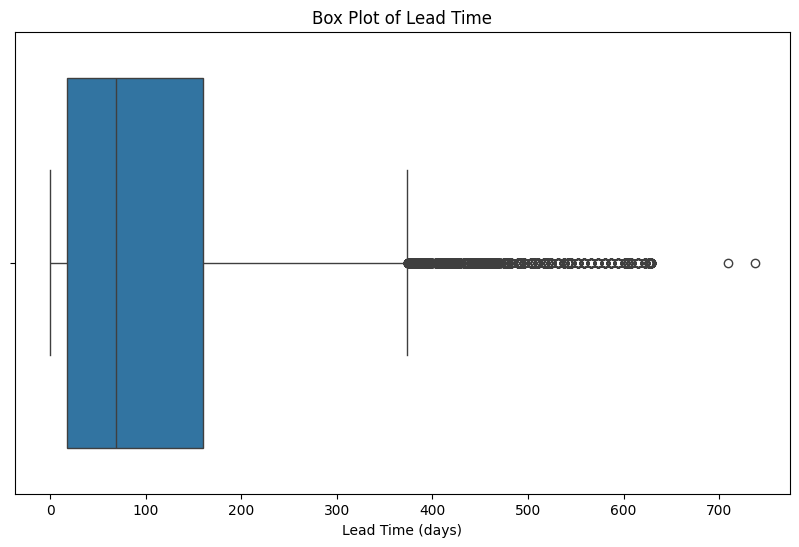

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['lead_time'])
plt.title('Box Plot of Lead Time')
plt.xlabel('Lead Time (days)')
plt.show()

**Observations from Histogram and Box Plot:**
*   **Shape and Skewness:** The `lead_time` distribution is highly right-skewed. The majority of bookings have a relatively short lead time, peaking sharply around 0-50 days. The mean (104 days) is significantly higher than the median (69 days), confirming this positive skewness.
*   **Spread:** The data is quite spread out, with a standard deviation of approximately 107 days. The interquartile range (IQR = 160 - 18 = 142 days) indicates a substantial variation in lead times for the central 50% of bookings.
*   **Outliers:** The box plot clearly shows a large number of outliers extending to very high lead times (up to 737 days). This suggests that while most bookings are made relatively close to the arrival date, a significant portion are planned much further in advance, representing extreme cases in booking behavior.

**Typical Booking Behavior:** Most guests tend to book their hotels less than 3 months in advance (75% of bookings have a lead time of 160 days or less). A large proportion, nearly 25%, book within 18 days of arrival.

**Extreme Cases:** Some bookings are made exceptionally far in advance, exceeding two years (max 737 days), which could be for special events, group bookings, or long-term travel plans.

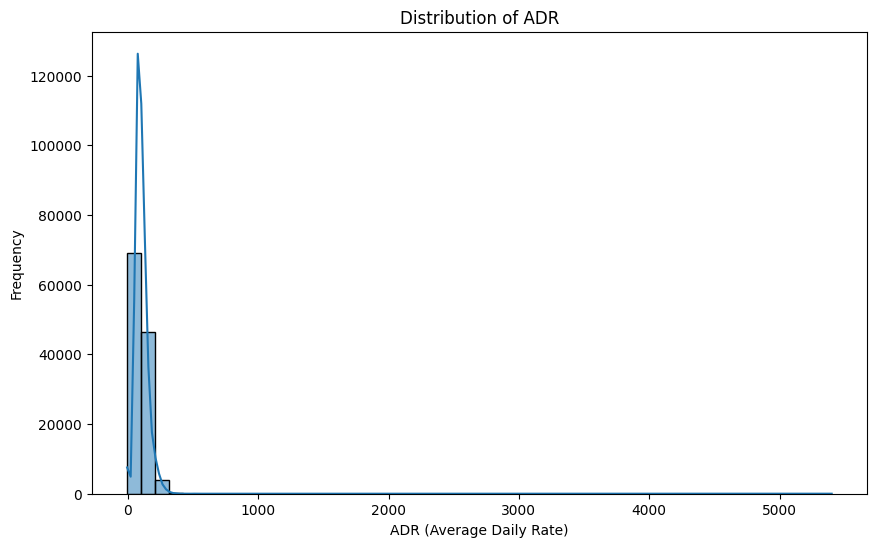

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['adr'], bins=50, kde=True)
plt.title('Distribution of ADR')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Frequency')
plt.show()

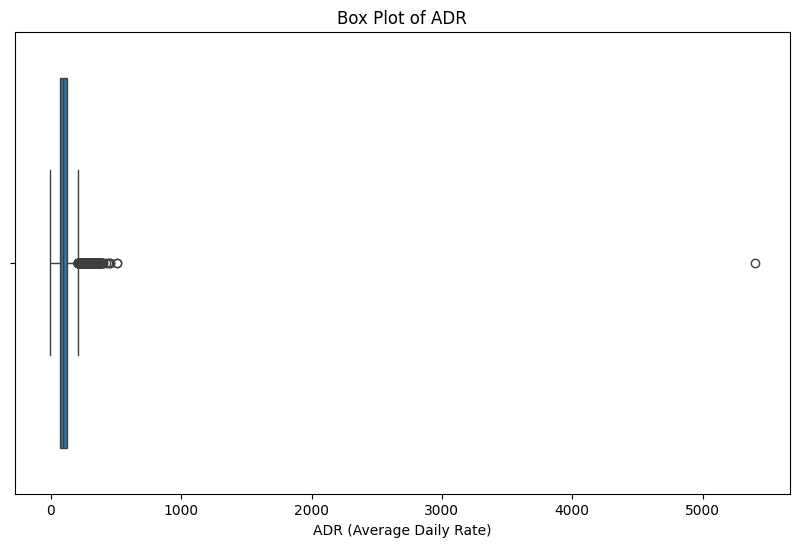

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['adr'])
plt.title('Box Plot of ADR')
plt.xlabel('ADR (Average Daily Rate)')
plt.show()

**Observations from Histogram and Box Plot:**
*   **Shape and Skewness:** The `adr` distribution is also highly right-skewed. The bulk of the ADR values are concentrated at the lower end, with a long tail extending towards higher values. The mean (101.83) is higher than the median (94.58), indicating positive skewness.
*   **Spread:** The standard deviation of 50.54 shows considerable variability in daily rates. The IQR (126 - 69.29 = 56.71) reflects the spread of the middle 50% of the rates.
*   **Outliers:** Both the histogram and especially the box plot highlight extreme outliers in ADR. There are values ranging from slightly negative (-6.38, which could indicate a data error or specific booking adjustments/refunds) to exceptionally high (5400). The vast majority of bookings fall within a much narrower range.

**Typical Pricing Behavior:** Most daily rates are between approximately 70 and 126. The most common rates are below 100.

**Extreme Cases:** The presence of a negative ADR is unusual and warrants investigation, as it could indicate data entry errors or specific promotional scenarios where the hotel essentially pays the guest. The extremely high ADR values suggest luxury bookings, special packages, or periods of very high demand.

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [ ]:
print("Descriptive statistics for lead_time by cancellation status:")
print(df.groupby('is_canceled')['lead_time'].describe())

Descriptive statistics for lead_time by cancellation status:
               count        mean         std  min   25%    50%    75%    max
is_canceled                                                                 
0            75166.0   79.984687   91.109888  0.0   9.0   45.0  124.0  737.0
1            44224.0  144.848815  118.624829  0.0  48.0  113.0  214.0  629.0


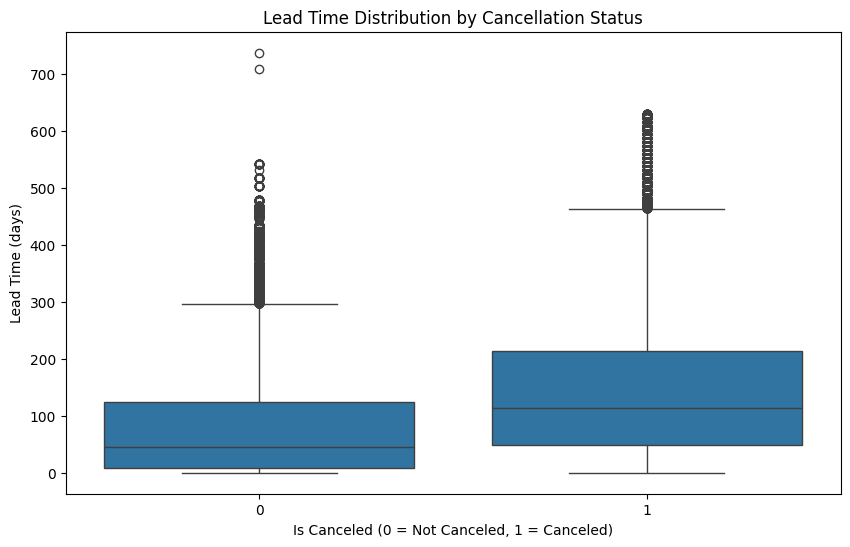

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Is Canceled (0 = Not Canceled, 1 = Canceled)')
plt.ylabel('Lead Time (days)')
plt.show()

**Pattern Observed:**

Bookings with longer lead times tend to be canceled more often than bookings with shorter lead times. This is evident from both the summary statistics and the box plot:

*   **Summary Statistics:** The mean lead time for canceled bookings (`is_canceled = 1`) is 144.85 days, significantly higher than the mean lead time of 79.98 days for non-canceled bookings (`is_canceled = 0`). The median also shows a similar trend: 113 days for canceled bookings versus 45 days for non-canceled bookings.

*   **Box Plot:** The box plot visually confirms this. The box for canceled bookings is shifted upwards, indicating that the bulk of these bookings (the interquartile range) have longer lead times. The median line within the box for canceled bookings is also considerably higher than for non-canceled bookings.

**Interaction of Variables:**

This pattern suggests a strong positive relationship between `lead_time` and the likelihood of cancellation. The longer the period between booking and arrival, the higher the probability that the booking will be canceled. This could be due to various factors, such as changes in travel plans, finding better deals, or unforeseen circumstances that are more likely to occur over a longer duration. While both groups show outliers with very long lead times, the central tendency and overall distribution for canceled bookings clearly lean towards longer lead times.

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [ ]:
monthly_adr = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()

# Define the order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_adr['arrival_date_month'] = pd.Categorical(monthly_adr['arrival_date_month'], categories=month_order, ordered=True)
monthly_adr = monthly_adr.sort_values('arrival_date_month')

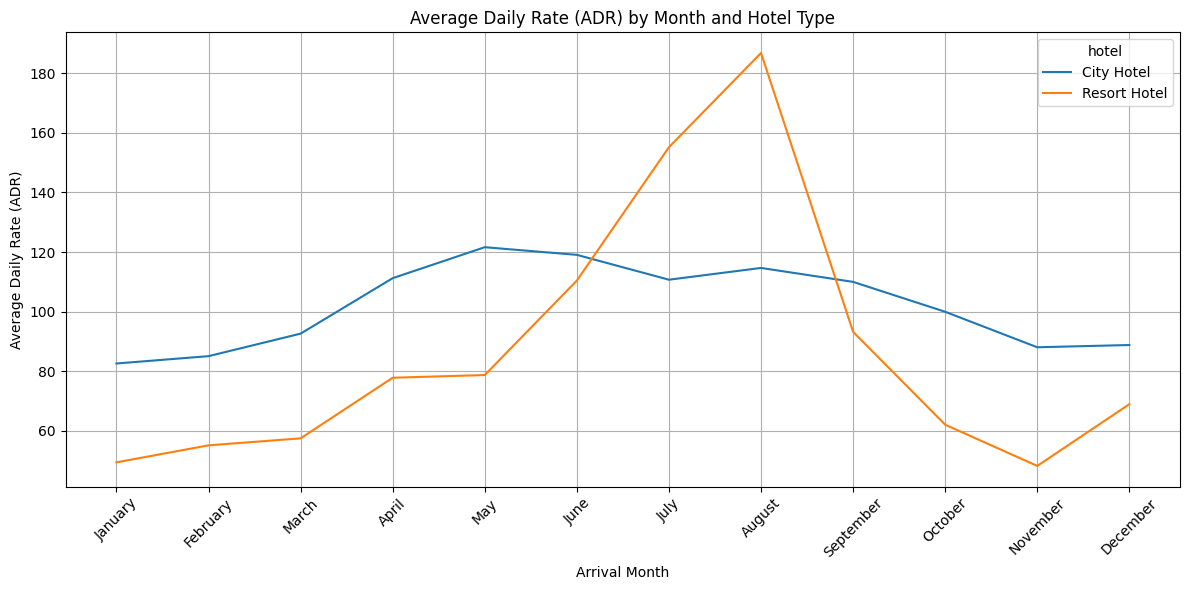

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=monthly_adr)
plt.title('Average Daily Rate (ADR) by Month and Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Seasonal Pricing Patterns Observed:**

**1. General Trend for City Hotels vs. Resort Hotels:**
*   **City Hotels** generally maintain a more consistent Average Daily Rate (ADR) throughout the year, with some fluctuations. Their ADR tends to be moderately high during most months, suggesting a steady demand that is less dependent on extreme seasonality.
*   **Resort Hotels** exhibit much more pronounced seasonal pricing. Their ADR is significantly lower during the colder months and rises sharply during the warmer, peak tourist seasons.

**2. Peak Seasons and Most Pronounced Differences:**
*   **Summer Peak (July-August):** The most significant difference is observed during the summer months, particularly **July and August**. Resort Hotels experience their highest ADRs during this period, surpassing City Hotels. This indicates a strong summer vacation demand for resort destinations.
    *   In August, Resort Hotel ADR peaks, while City Hotel ADR is also high but not as dramatically elevated, making this the month with the largest absolute difference in pricing between the two hotel types.
*   **Winter/Early Spring Trough (January-April):** Conversely, the ADR for Resort Hotels is lowest during these months, falling considerably below that of City Hotels. This period shows that City Hotels are able to command higher prices during what is likely an off-season for resort destinations.

**In summary, Resort Hotels show a strong dependency on seasonal demand, with high peaks in summer and deep troughs in winter, whereas City Hotels maintain more stable pricing with moderate peaks, suggesting a broader, less season-dependent customer base. The differences are most pronounced in the summer (highest for resorts) and winter (lowest for resorts).**

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [ ]:
cancellation_rates = df.groupby('is_repeated_guest')['is_canceled'].mean().reset_index()
print("Cancellation rates by guest type:")
print(cancellation_rates)

Cancellation rates by guest type:
   is_repeated_guest  is_canceled
0                  0     0.377851
1                  1     0.144882


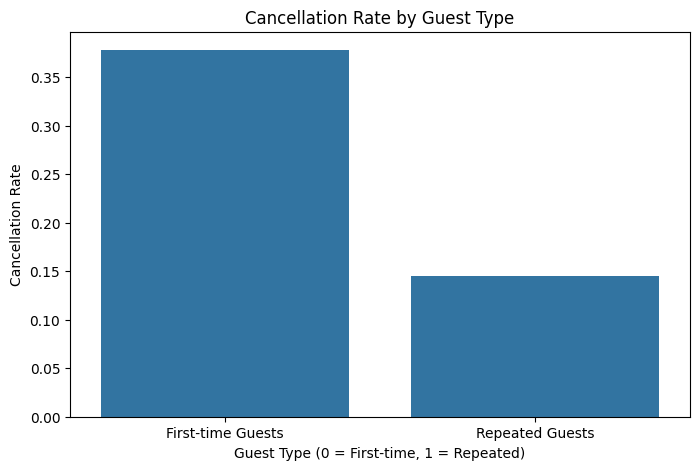

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='is_repeated_guest', y='is_canceled', data=cancellation_rates)
plt.title('Cancellation Rate by Guest Type')
plt.xlabel('Guest Type (0 = First-time, 1 = Repeated)')
plt.ylabel('Cancellation Rate')
plt.xticks(ticks=[0, 1], labels=['First-time Guests', 'Repeated Guests'])
plt.show()

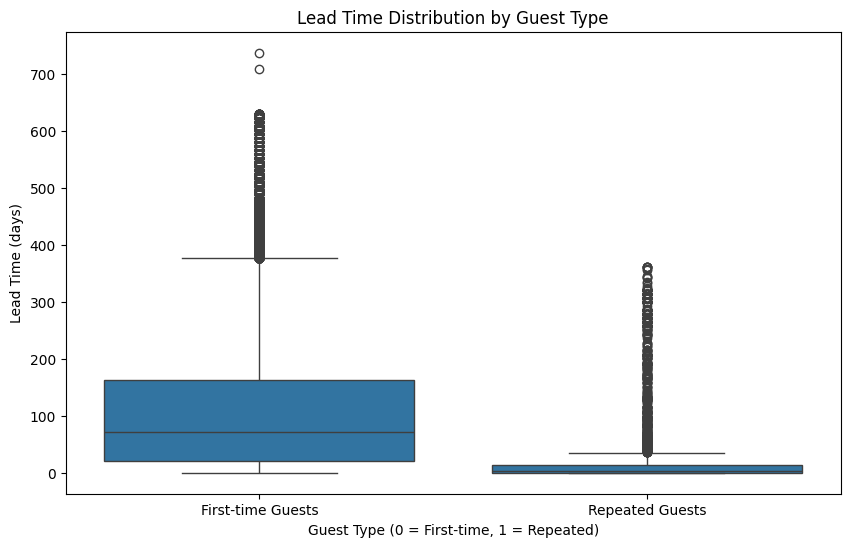

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_repeated_guest', y='lead_time', data=df)
plt.title('Lead Time Distribution by Guest Type')
plt.xlabel('Guest Type (0 = First-time, 1 = Repeated)')
plt.ylabel('Lead Time (days)')
plt.xticks(ticks=[0, 1], labels=['First-time Guests', 'Repeated Guests'])
plt.show()

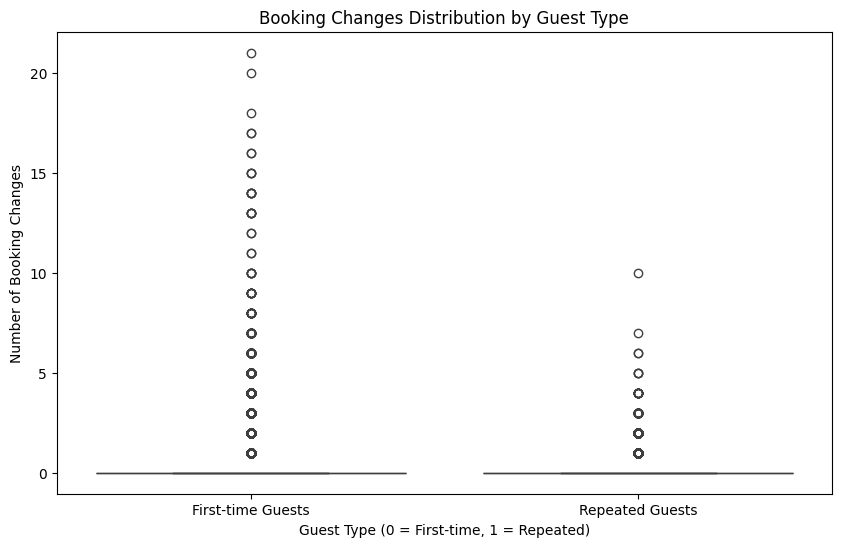

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_repeated_guest', y='booking_changes', data=df)
plt.title('Booking Changes Distribution by Guest Type')
plt.xlabel('Guest Type (0 = First-time, 1 = Repeated)')
plt.ylabel('Number of Booking Changes')
plt.xticks(ticks=[0, 1], labels=['First-time Guests', 'Repeated Guests'])
plt.show()

### Data Analysis Key Findings
*   First-time guests (is\_repeated\_guest = 0) exhibit a cancellation rate of approximately 37.8%, which is significantly higher than the 14.5% observed for repeated guests (is\_repeated\_guest = 1).
*   First-time guests plan their bookings much earlier, reflected in a mean lead time of about 105.7 days and a median of 69 days.
*   Repeated guests tend to book with shorter notice, having a mean lead time of approximately 26.9 days and a median of 6 days.
*   Regarding booking changes, first-time guests have a mean of approximately 0.22 changes per booking, with a maximum of 21 changes.
*   Repeated guests show a slightly higher mean of approximately 0.26 booking changes, with a maximum of 10 changes. For both groups, the 25th, 50th, and 75th percentiles for booking changes are 0, indicating that most bookings experience no modifications.

### Comparison of Booking Behavior for First-time vs. Repeated Guests

**1. Cancellation Rate:**
*   **First-time Guests (is_repeated_guest = 0):** Have a significantly higher cancellation rate of approximately **37.8%**.
*   **Repeated Guests (is_repeated_guest = 1):** Have a much lower cancellation rate of about **14.5%**.

This indicates that repeated guests are more reliable and less likely to cancel their bookings, suggesting higher loyalty and commitment.

**2. Lead Time:**
*   **First-time Guests (is_repeated_guest = 0):** Have a mean lead time of approximately **105.7 days** and a median of **69 days**. The box plot shows a wider spread and a considerable number of bookings with very long lead times.
*   **Repeated Guests (is_repeated_guest = 1):** Have a much shorter mean lead time of about **26.9 days** and a median of **6 days**. The box plot is much more concentrated at lower lead times.

This suggests that repeated guests tend to book closer to their arrival date, possibly due to familiarity with the hotel or last-minute decisions, while first-time guests often plan their stays further in advance.

**3. Booking Changes:**
*   **First-time Guests (is_repeated_guest = 0):** The mean number of booking changes is approximately **0.22**, with a maximum of 21 changes. The 25th, 50th, and 75th percentiles are all 0, indicating that most first-time guests do not make any changes.
*   **Repeated Guests (is_repeated_guest = 1):** The mean number of booking changes is approximately **0.26**, slightly higher than first-time guests, with a maximum of 10 changes. Similar to first-time guests, the 25th, 50th, and 75th percentiles are 0, meaning most repeated guests also do not make changes.

While the mean for repeated guests is slightly higher, the overall distribution for both groups shows that the vast majority of bookings experience no changes. The slight difference in mean might suggest that repeated guests, being more familiar, might feel more comfortable making minor adjustments, but the impact is minimal.

**Summary of Differences in Booking and Cancellation Behaviors:**

Repeated guests exhibit significantly more desirable booking behavior from a hotel's perspective:
*   They have a **much lower cancellation rate**, indicating higher certainty in their bookings.
*   They tend to book with **shorter lead times**, which might simplify inventory management for hotels.
*   Their tendency to make booking changes is **similar to first-time guests**, with most bookings having no changes, though they show a slightly higher mean. This suggests that while they are familiar, it does not translate into substantially more modifications.

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


In [ ]:
cancellation_rate_by_deposit = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
print("Cancellation rates by Deposit Type:")
print(cancellation_rate_by_deposit)

Cancellation rates by Deposit Type:
  deposit_type  is_canceled
0   No Deposit     0.283770
1   Non Refund     0.993624
2   Refundable     0.222222


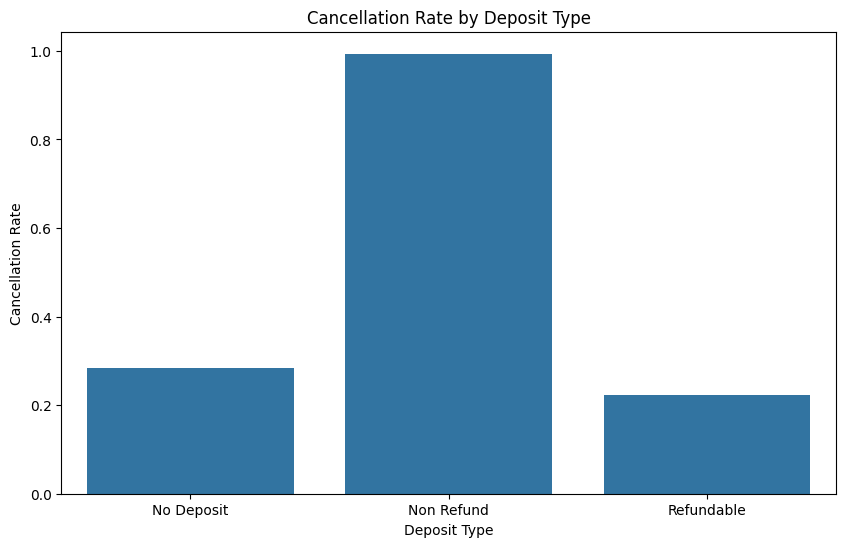

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='deposit_type', y='is_canceled', data=cancellation_rate_by_deposit)
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
plt.show()

In [ ]:
print("Descriptive statistics for Lead Time grouped by Deposit Type and Cancellation Status:")
print(df.groupby(['deposit_type', 'is_canceled'])['lead_time'].describe())

Descriptive statistics for Lead Time grouped by Deposit Type and Cancellation Status:
                            count        mean         std  min    25%    50%  \
deposit_type is_canceled                                                       
No Deposit   0            74947.0   79.832201   91.059809  0.0    9.0   45.0   
             1            29694.0  111.281639   94.005354  0.0   35.0   86.0   
Non Refund   0               93.0  106.215054   79.010023  0.0   17.0  171.0   
             1            14494.0  213.593487  133.327851  0.0  103.0  186.0   
Refundable   0              126.0  151.325397   98.805492  0.0   54.5  169.0   
             1               36.0  154.805556   94.478968  1.0   88.5  169.0   

                            75%    max  
deposit_type is_canceled                
No Deposit   0            124.0  737.0  
             1            169.0  518.0  
Non Refund   0            171.0  226.0  
             1            305.0  629.0  
Refundable   0            1

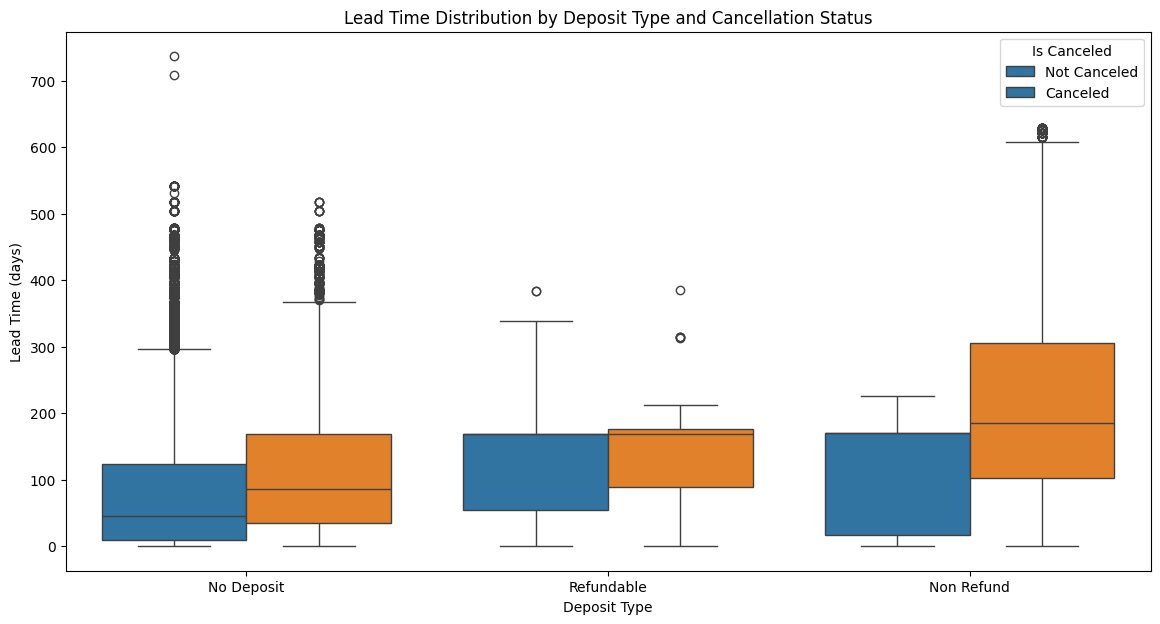

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='deposit_type', y='lead_time', hue='is_canceled', data=df)
plt.title('Lead Time Distribution by Deposit Type and Cancellation Status')
plt.xlabel('Deposit Type')
plt.ylabel('Lead Time (days)')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Cancellation Rate by Deposit Type:**
    *   The 'Non Refund' deposit type exhibits an exceptionally high cancellation rate, approximately 99.36%.
    *   'No Deposit' bookings have a cancellation rate of about 28.38%.
    *   'Refundable' bookings show the lowest cancellation rate, around 22.22%.
*   **Interaction of Lead Time with 'Non Refund' Deposits and Cancellations:**
    *   For 'Non Refund' bookings, canceled bookings have a significantly higher mean `lead_time` (approximately 213.59 days) compared to non-canceled bookings (approximately 106.21 days). This indicates that longer lead times for non-refundable bookings strongly correlate with cancellation.
*   **Lead Time for 'No Deposit' Bookings:**
    *   Canceled 'No Deposit' bookings also show a higher mean `lead_time` (approximately 111.28 days) than non-canceled ones (approximately 79.83 days), suggesting that longer lead times generally increase the likelihood of cancellation in this category as well.
*   **Lead Time for 'Refundable' Deposits:**
    *   For 'Refundable' bookings, the mean `lead_time` is similar for both canceled (approximately 154.81 days) and non-canceled (approximately 151.33 days) bookings, implying that `lead_time` is less of a distinguishing factor for cancellation when the deposit is refundable.
